# Análise Financeira com Python - ClearBank

**Desafio prático | solução principal com a biblioteca padrão do Python**

Este notebook lê `transacoes.csv`, descarta registros inválidos e IDs duplicados,
calcula sete métricas por mês, sinaliza valores **acima** de R$ 10.000,00,
imprime o relatório e gera `relatorio.json`. Ao final, os dois requisitos
opcionais comparam os cálculos com pandas e salvam `grafico.png` com matplotlib.

Os dados são fictícios. A sinalização indica uma regra de valor para análise;
ela não é uma conclusão sobre fraude.

## Antes de executar

1. Use **Python 3.10 ou superior**. No Jupyter, abra este arquivo na pasta do projeto.
2. Mantenha `transacoes.csv` e `analise_pandas.py` na mesma pasta do notebook.
   O CSV já foi criado manualmente: **não é gerado pelas células**.
3. Instale os extras com `python -m pip install -r requirements.txt`.
   A parte principal, até a execução do relatório, não depende de pandas ou matplotlib.
4. No Google Colab, abra o `.ipynb` e faça upload de `transacoes.csv` e
   `analise_pandas.py` na aba **Arquivos**. Se necessário, instale
   `pandas` e `matplotlib` com `%pip install pandas matplotlib` em uma célula temporária.
5. Execute **todas as células em ordem** e salve o notebook com as saídas.

A base contém 33 registros: 18 válidos em janeiro, fevereiro e março de 2026,
14 com campos inválidos e 1 duplicata. Há 2 valores acima do limite.
A primeira ocorrência **válida** de cada ID é mantida; repetições posteriores
contam como inválidas e também são identificadas no contador de duplicatas.

Valores são convertidos para `float`, conforme o requisito, e as somas usam
`Decimal(str(valor))` para evitar erros de acumulação de centavos. O relatório
arredonda as métricas a duas casas usando `ROUND_HALF_UP`; a média é calculada
sobre **todos** os valores positivos do mês, incluindo créditos e débitos.

## 1. Preparação e constante de suspeita

Os imports desta seção são todos da biblioteca padrão. O limite é definido
uma única vez e vale tanto para a solução nativa quanto para a comparação opcional.

In [1]:
import csv
import json
import math
import re
import sys
from contextlib import redirect_stdout
from datetime import date, datetime
from decimal import Decimal, ROUND_HALF_UP
from io import StringIO
from pathlib import Path
from tempfile import TemporaryDirectory

LIMITE_SUSPEITO = 10000.00
COLUNAS_ESPERADAS = ("id", "data", "cliente_id", "tipo", "valor", "descricao", "categoria")
ARQUIVO_CSV = Path("transacoes.csv")
ARQUIVO_JSON = Path("relatorio.json")

assert sys.version_info >= (3, 10), "Use Python 3.10 ou superior."
print(f"Python {sys.version.split()[0]} | solução nativa preparada")
print(f"Limite de suspeita: R$ {LIMITE_SUSPEITO:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

Python 3.12.14 | solução nativa preparada
Limite de suspeita: R$ 10.000,00


## 2. Leitura do CSV com `csv.DictReader`

A leitura usa nomes de colunas e `with open`. Um arquivo ausente ou com
cabeçalho incompleto gera uma mensagem e retorna `None`, permitindo que a
execução principal termine de forma controlada. `utf-8-sig` também aceita BOM.

In [2]:
def ler_transacoes(caminho):
    """Retorna registros brutos; None indica que o arquivo não pôde ser lido."""
    try:
        with open(caminho, encoding="utf-8-sig", newline="") as arquivo:
            leitor = csv.DictReader(arquivo)
            colunas = leitor.fieldnames or []
            faltantes = set(COLUNAS_ESPERADAS) - set(colunas)
            if faltantes or len(colunas) != len(set(colunas)):
                print("CSV com cabeçalho inválido. Confira as sete colunas esperadas.")
                return None
            return list(leitor)
    except FileNotFoundError:
        print(f"Arquivo CSV não encontrado: {Path(caminho).name}")
        return None
    except (OSError, UnicodeError, csv.Error) as erro:
        print(f"Não foi possível ler o CSV: {erro}")
        return None


with TemporaryDirectory() as pasta_teste:
    pasta_teste = Path(pasta_teste)
    csv_teste = pasta_teste / "leitura.csv"
    csv_teste.write_text(
        'id,data,cliente_id,tipo,valor,descricao,categoria\n'
        '1,2026-01-05,CLI001,credito,3500.00,"Salário, janeiro",salario\n',
        encoding="utf-8-sig",
    )
    registros_teste = ler_transacoes(csv_teste)
    assert registros_teste[0]["descricao"] == "Salário, janeiro"
    assert registros_teste[0]["valor"] == "3500.00"
    assert ler_transacoes(pasta_teste / "arquivo_nao_existe.csv") is None
    csv_teste.write_text("id,data\n1,2026-01-05\n", encoding="utf-8")
    assert ler_transacoes(csv_teste) is None
print("Leitura validada: colunas por nome, vírgula entre aspas, BOM e erros de arquivo.")

Arquivo CSV não encontrado: arquivo_nao_existe.csv
CSV com cabeçalho inválido. Confira as sete colunas esperadas.
Leitura validada: colunas por nome, vírgula entre aspas, BOM e erros de arquivo.


## 3. Validação de cada transação

A data deve ter exatamente o formato `AAAA-MM-DD` e existir no calendário.
O ID deve ser inteiro, o cliente não pode estar vazio, o tipo deve ser
`credito` ou `debito` e o valor deve ser numérico, finito e maior que zero.
Cada linha inválida retorna `None` **sem imprimir mensagens individuais**.

In [3]:
def validar_data(texto):
    """Converte uma data estrita AAAA-MM-DD; rejeita datas inexistentes."""
    if not re.fullmatch(r"[0-9]{4}-[0-9]{2}-[0-9]{2}", texto):
        return None
    try:
        return datetime.strptime(texto, "%Y-%m-%d")
    except ValueError:
        return None


def validar_valor(texto):
    """Converte para float e rejeita zero, negativos, NaN e infinito."""
    try:
        valor = float(texto)
    except (ValueError, TypeError, OverflowError):
        return None
    return valor if math.isfinite(valor) and valor > 0 else None


def validar_transacao(linha):
    """Devolve um registro limpo ou None, sem interromper a leitura do lote."""
    if None in linha:  # DictReader usa None como chave de campos excedentes.
        return None
    textos = {coluna: str(linha.get(coluna) or "").strip() for coluna in COLUNAS_ESPERADAS}
    if not re.fullmatch(r"[+-]?[0-9]+", textos["id"]):
        return None
    try:
        identificador = int(textos["id"])
    except ValueError:
        return None
    if not textos["cliente_id"] or textos["tipo"] not in {"credito", "debito"}:
        return None
    data_transacao = validar_data(textos["data"])
    valor = validar_valor(textos["valor"])
    if data_transacao is None or valor is None:
        return None
    return {**textos, "id": identificador, "data": data_transacao, "valor": valor}


linha_base = {"id": "99", "data": "2026-01-01", "cliente_id": "CLI099",
              "tipo": "credito", "valor": "100.00", "descricao": "Teste", "categoria": "teste"}
casos_invalidos = [
    ("id", ""), ("id", "abc"), ("id", "19.5"),
    ("cliente_id", ""), ("cliente_id", "   "),
    ("data", "2026/01/01"), ("data", "2026-02-30"), ("data", "2026-1-01"),
    ("tipo", "pix"), ("tipo", "Credito"),
    ("valor", "abc"), ("valor", "0"), ("valor", "-0.01"),
    ("valor", "nan"), ("valor", "inf"), ("valor", "-inf"),
]
saida_validacao = StringIO()
with redirect_stdout(saida_validacao):
    for campo, valor_invalido in casos_invalidos:
        assert validar_transacao({**linha_base, campo: valor_invalido}) is None
    for campo in ("id", "data", "cliente_id", "tipo", "valor"):
        sem_campo = {chave: valor for chave, valor in linha_base.items() if chave != campo}
        assert validar_transacao(sem_campo) is None
    assert validar_transacao({**linha_base, None: ["campo extra"]}) is None
assert saida_validacao.getvalue() == "", "A validação deve descartar linhas silenciosamente."
limpa = validar_transacao({**linha_base, "data": "2024-02-29", "valor": " 0.10 "})
assert limpa["id"] == 99 and isinstance(limpa["data"], datetime) and limpa["valor"] == 0.10
print("Validação aprovada: 22 casos inválidos, descarte silencioso e ano bissexto válido.")

Validação aprovada: 22 casos inválidos, descarte silencioso e ano bissexto válido.


## 4. Limpeza do lote e IDs duplicados

O contador de inválidas inclui registros com campos inválidos e duplicatas.
IDs equivalentes após a conversão para inteiro representam a mesma transação.
A verificação acontece depois da validação, para que uma linha inválida não
impeça o uso de uma ocorrência válida posterior do mesmo ID.

In [4]:
def validar_transacoes(linhas):
    """Valida o lote, mantém o primeiro ID válido e contabiliza a limpeza."""
    validas, ids_encontrados = [], set()
    estatisticas = {"total_lidas": len(linhas), "validas": 0, "invalidas": 0, "duplicadas": 0}
    for linha in linhas:
        transacao = validar_transacao(linha)
        if transacao is None:
            estatisticas["invalidas"] += 1
        elif transacao["id"] in ids_encontrados:
            estatisticas["invalidas"] += 1
            estatisticas["duplicadas"] += 1
        else:
            ids_encontrados.add(transacao["id"])
            validas.append(transacao)
    estatisticas["validas"] = len(validas)
    return validas, estatisticas


linhas = ler_transacoes(ARQUIVO_CSV)
assert linhas is not None, "Coloque transacoes.csv na mesma pasta do notebook."
transacoes_validas, estatisticas = validar_transacoes(linhas)
assert estatisticas == {"total_lidas": 33, "validas": 18, "invalidas": 15, "duplicadas": 1}
assert len({transacao["id"] for transacao in transacoes_validas}) == 18
teste_ids = [{**linha_base, "valor": "abc"}, linha_base, {**linha_base, "id": "099"}]
validas_ids, contagem_ids = validar_transacoes(teste_ids)
assert len(validas_ids) == 1 and contagem_ids["invalidas"] == 2 and contagem_ids["duplicadas"] == 1
print(f"Total de linhas lidas: {estatisticas['total_lidas']}")
print(f"Linhas válidas: {estatisticas['validas']}")
print(f"Linhas inválidas: {estatisticas['invalidas']}")
print(f"Duplicatas descartadas (incluídas nas inválidas): {estatisticas['duplicadas']}")

Total de linhas lidas: 33
Linhas válidas: 18
Linhas inválidas: 15
Duplicatas descartadas (incluídas nas inválidas): 1


## 5. Datas e período analisado

O mês é extraído com `strftime("%Y-%m")`. O intervalo é a diferença em dias
entre a data mais antiga e a mais recente, usando apenas transações válidas.
Uma base sem transações válidas não possui período e retorna `None`.

In [5]:
def calcular_periodo(transacoes):
    """Obtém os extremos das datas válidas e a diferença em dias."""
    if not transacoes:
        return None
    datas = [transacao["data"] for transacao in transacoes]
    primeira, ultima = min(datas), max(datas)
    return {"data_inicio": primeira.strftime("%Y-%m-%d"),
            "data_fim": ultima.strftime("%Y-%m-%d"), "dias": (ultima - primeira).days}


periodo_esperado = {"data_inicio": "2026-01-05", "data_fim": "2026-03-31", "dias": 85}
assert calcular_periodo(transacoes_validas[::-1]) == periodo_esperado
assert calcular_periodo([]) is None
assert calcular_periodo([transacoes_validas[0]])["dias"] == 0
assert transacoes_validas[0]["data"].strftime("%Y-%m") == "2026-01"
print("Período validado: 2026-01-05 → 2026-03-31 | 85 dias")
print("Datas fora de ordem, base vazia e período de um único dia também foram testados.")

Período validado: 2026-01-05 → 2026-03-31 | 85 dias
Datas fora de ordem, base vazia e período de um único dia também foram testados.


## 6. Agrupamento mensal, sete métricas e suspeitas

Para cada mês: quantidade, total de crédito, total de débito, saldo,
valor médio, maior valor e menor valor. As suspeitas guardam `id`,
`cliente_id`, `data` e `valor`. A comparação usa `valor > LIMITE_SUSPEITO`.
A ordem dos meses é cronológica e nenhuma data ou `Decimal` fica no JSON.

In [6]:
def arredondar_moeda(valor):
    """Converte o resultado financeiro em número JSON com duas casas."""
    return float(valor.quantize(Decimal("0.01"), rounding=ROUND_HALF_UP))


def gerar_relatorio(transacoes, estatisticas, gerado_em=None):
    """Calcula as métricas mensais e prepara uma estrutura serializável."""
    grupos = {}
    for transacao in transacoes:
        mes = transacao["data"].strftime("%Y-%m")
        grupos.setdefault(mes, []).append(transacao)
    resumo = {}
    for mes in sorted(grupos):
        registros = grupos[mes]
        valores = [Decimal(str(transacao["valor"])) for transacao in registros]
        credito = sum((valor for transacao, valor in zip(registros, valores)
                       if transacao["tipo"] == "credito"), Decimal("0"))
        debito = sum((valor for transacao, valor in zip(registros, valores)
                      if transacao["tipo"] == "debito"), Decimal("0"))
        resumo[mes] = {
            "quantidade": len(registros),
            "total_credito": arredondar_moeda(credito),
            "total_debito": arredondar_moeda(debito),
            "saldo": arredondar_moeda(credito - debito),
            "media": arredondar_moeda(sum(valores, Decimal("0")) / len(registros)),
            "maior_valor": arredondar_moeda(max(valores)),
            "menor_valor": arredondar_moeda(min(valores)),
        }
    suspeitas = [
        {"id": transacao["id"], "cliente_id": transacao["cliente_id"],
         "data": transacao["data"].strftime("%Y-%m-%d"), "valor": transacao["valor"]}
        for transacao in transacoes if transacao["valor"] > LIMITE_SUSPEITO
    ]
    return {
        "gerado_em": gerado_em or date.today().isoformat(),
        "total_linhas_lidas": estatisticas["total_lidas"],
        "total_transacoes_validas": len(transacoes),
        "total_transacoes_invalidas": estatisticas["invalidas"],
        "total_duplicadas": estatisticas["duplicadas"],
        "periodo_analisado": calcular_periodo(transacoes),
        "resumo_mensal": resumo,
        "transacoes_suspeitas": suspeitas,
    }


resumo_esperado = {
    "2026-01": {"quantidade": 6, "total_credito": 20300.00, "total_debito": 1530.40,
                "saldo": 18769.60, "media": 3638.40, "maior_valor": 12000.00, "menor_valor": 180.50},
    "2026-02": {"quantidade": 6, "total_credito": 20700.00, "total_debito": 1269.90,
                "saldo": 19430.10, "media": 3661.65, "maior_valor": 15000.00, "menor_valor": 99.90},
    "2026-03": {"quantidade": 6, "total_credito": 8200.10, "total_debito": 10850.20,
                "saldo": -2650.10, "media": 3175.05, "maior_valor": 10000.00, "menor_valor": 0.10},
}
relatorio_teste = gerar_relatorio(transacoes_validas, estatisticas)
assert relatorio_teste["resumo_mensal"] == resumo_esperado
assert relatorio_teste["periodo_analisado"] == periodo_esperado
assert [transacao["id"] for transacao in relatorio_teste["transacoes_suspeitas"]] == [5, 10]
assert all(transacao["id"] != 16 for transacao in relatorio_teste["transacoes_suspeitas"])
vazias = {"total_lidas": 0, "validas": 0, "invalidas": 0, "duplicadas": 0}
relatorio_vazio = gerar_relatorio([], vazias)
assert relatorio_vazio["resumo_mensal"] == {} and relatorio_vazio["transacoes_suspeitas"] == []
assert relatorio_vazio["periodo_analisado"] is None
centavos = [validar_transacao({**linha_base, "id": str(i), "valor": valor})
            for i, valor in ((1, "0.01"), (2, "0.02"))]
relatorio_centavos = gerar_relatorio(centavos, {**vazias, "total_lidas": 2, "validas": 2})
assert relatorio_centavos["resumo_mensal"]["2026-01"]["total_credito"] == 0.03
assert relatorio_centavos["resumo_mensal"]["2026-01"]["media"] == 0.02
print("As 21 métricas dos três meses conferem com os valores esperados.")
print("Suspeitas: IDs 5 e 10. O ID 16, de R$ 10.000,00 exatos, não é suspeito.")
print("Centavos, arredondamento e relatório sem transações também foram validados.")

As 21 métricas dos três meses conferem com os valores esperados.
Suspeitas: IDs 5 e 10. O ID 16, de R$ 10.000,00 exatos, não é suspeito.
Centavos, arredondamento e relatório sem transações também foram validados.


## 7. Exportação para `relatorio.json`

`json.dump` preserva acentos (`ensure_ascii=False`) e usa indentação de duas
posições. `allow_nan=False` garante um JSON válido. Erros de escrita também
são tratados com mensagem, sem encerramento abrupto.

In [7]:
def salvar_json(relatorio, caminho="relatorio.json"):
    """Salva o relatório formatado; informa sucesso ou falha de gravação."""
    try:
        with open(caminho, "w", encoding="utf-8") as arquivo:
            json.dump(relatorio, arquivo, ensure_ascii=False, indent=2, allow_nan=False)
            arquivo.write("\n")
        return True
    except (OSError, TypeError, ValueError) as erro:
        print(f"Não foi possível salvar o JSON: {erro}")
        return False


with TemporaryDirectory() as pasta_teste:
    destino = Path(pasta_teste) / "relatorio_teste.json"
    assert salvar_json(relatorio_teste, destino)
    assert json.loads(destino.read_text(encoding="utf-8")) == relatorio_teste
    assert salvar_json({"mensagem": "Análise concluída"}, destino)
    assert "Análise concluída" in destino.read_text(encoding="utf-8")
    saida_erro = StringIO()
    with redirect_stdout(saida_erro):
        assert not salvar_json(relatorio_teste, Path(pasta_teste) / "pasta_inexistente" / "r.json")
    assert "Não foi possível salvar o JSON" in saida_erro.getvalue()
print("JSON validado: leitura de volta, acentos, estrutura e erro de gravação tratado.")

JSON validado: leitura de volta, acentos, estrutura e erro de gravação tratado.


## 8. Relatório formatado na saída da célula

Valores monetários usam `R$`, separador brasileiro e duas casas decimais.
A saída mostra o período, dias decorridos, contagens, meses e suspeitas.

In [8]:
def formatar_moeda(valor):
    """Formata um valor no padrão brasileiro sem depender de locale."""
    numero = f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"R$ {numero}"


def exibir_relatorio(relatorio):
    """Imprime as seções de limpeza, período, métricas mensais e suspeitas."""
    print("===== ANÁLISE FINANCEIRA - CLEARBANK =====")
    print(f"Gerado em: {relatorio['gerado_em']}")
    periodo = relatorio["periodo_analisado"]
    if periodo:
        print(f"Período analisado: {periodo['data_inicio']} → {periodo['data_fim']}")
        print(f"Dias entre a transação mais antiga e a mais recente: {periodo['dias']}")
    else:
        print("Período analisado: sem transações válidas.")
    print("\n===== RESUMO DA LIMPEZA =====")
    print(f"Total de linhas lidas: {relatorio['total_linhas_lidas']}")
    print(f"Linhas válidas: {relatorio['total_transacoes_validas']}")
    print(f"Linhas inválidas: {relatorio['total_transacoes_invalidas']}")
    print(f"Duplicatas descartadas (incluídas nas inválidas): {relatorio['total_duplicadas']}")
    print("\n===== RELATÓRIO MENSAL =====")
    if not relatorio["resumo_mensal"]:
        print("Nenhuma transação válida para calcular as métricas.")
    metricas = (("Total crédito", "total_credito"), ("Total débito", "total_debito"),
                ("Saldo", "saldo"), ("Média", "media"),
                ("Maior valor", "maior_valor"), ("Menor valor", "menor_valor"))
    for mes, resumo in relatorio["resumo_mensal"].items():
        print(f"\nMês: {mes}")
        print(f"  Transações:   {resumo['quantidade']}")
        for rotulo, chave in metricas:
            print(f"  {rotulo + ':':<16}{formatar_moeda(resumo[chave])}")
    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    for transacao in relatorio["transacoes_suspeitas"]:
        print(f"ID: {transacao['id']} | Cliente: {transacao['cliente_id']} | "
              f"Data: {transacao['data']} | Valor: {formatar_moeda(transacao['valor'])}")
    if not relatorio["transacoes_suspeitas"]:
        print("Nenhuma transação suspeita encontrada.")


assert formatar_moeda(3500) == "R$ 3.500,00"
assert formatar_moeda(-2650.10) == "R$ -2.650,10"
assert formatar_moeda(0.10) == "R$ 0,10"
saida_terminal = StringIO()
with redirect_stdout(saida_terminal):
    exibir_relatorio(relatorio_teste)
assert "R$ 19.430,10" in saida_terminal.getvalue() and "ID: 10 | Cliente: CLI003" in saida_terminal.getvalue()
saida_vazia = StringIO()
with redirect_stdout(saida_vazia):
    exibir_relatorio(relatorio_vazio)
assert "Nenhuma transação suspeita encontrada." in saida_vazia.getvalue()
assert "sem transações válidas" in saida_vazia.getvalue()
print("Formatação validada: reais, duas casas, saldo negativo e ausência de suspeitas.")

Formatação validada: reais, duas casas, saldo negativo e ausência de suspeitas.


## 9. Célula de Execução Principal

Esta célula reúne leitura, validação, métricas, terminal e JSON. A função
retorna de forma controlada se o arquivo estiver ausente. Nenhuma célula
anterior cria ou altera `transacoes.csv`.

In [9]:
def executar_analise(arquivo_csv="transacoes.csv", arquivo_json="relatorio.json"):
    """Executa o fluxo completo da solução nativa."""
    registros = ler_transacoes(arquivo_csv)
    if registros is None:
        print("Análise não executada. Confira o arquivo de entrada e tente novamente.")
        return None
    validas, contagem = validar_transacoes(registros)
    resultado = gerar_relatorio(validas, contagem)
    exibir_relatorio(resultado)
    if salvar_json(resultado, arquivo_json):
        print(f"\nArquivo gerado: {Path(arquivo_json).name}")
    return resultado


with TemporaryDirectory() as pasta_teste:
    saida_ausente = StringIO()
    destino_ausente = Path(pasta_teste) / "nao_deve_ser_criado.json"
    with redirect_stdout(saida_ausente):
        assert executar_analise(Path(pasta_teste) / "ausente.csv", destino_ausente) is None
    assert not destino_ausente.exists()
    assert "Análise não executada" in saida_ausente.getvalue()
print("Teste do fluxo com arquivo ausente aprovado.\n")

relatorio = executar_analise(ARQUIVO_CSV, ARQUIVO_JSON)
assert relatorio is not None
assert relatorio["resumo_mensal"] == resumo_esperado
assert ARQUIVO_JSON.is_file()

Teste do fluxo com arquivo ausente aprovado.

===== ANÁLISE FINANCEIRA - CLEARBANK =====
Gerado em: 2026-10-04
Período analisado: 2026-01-05 → 2026-03-31
Dias entre a transação mais antiga e a mais recente: 85

===== RESUMO DA LIMPEZA =====
Total de linhas lidas: 33
Linhas válidas: 18
Linhas inválidas: 15
Duplicatas descartadas (incluídas nas inválidas): 1

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações:   6
  Total crédito:  R$ 20.300,00
  Total débito:   R$ 1.530,40
  Saldo:          R$ 18.769,60
  Média:          R$ 3.638,40
  Maior valor:    R$ 12.000,00
  Menor valor:    R$ 180,50

Mês: 2026-02
  Transações:   6
  Total crédito:  R$ 20.700,00
  Total débito:   R$ 1.269,90
  Saldo:          R$ 19.430,10
  Média:          R$ 3.661,65
  Maior valor:    R$ 15.000,00
  Menor valor:    R$ 99,90

Mês: 2026-03
  Transações:   6
  Total crédito:  R$ 8.200,10
  Total débito:   R$ 10.850,20
  Saldo:          R$ -2.650,10
  Média:          R$ 3.175,05
  Maior valor:    R$ 10.000,00
 

## 10. Opcional R01 - comparação com pandas

O arquivo separado `analise_pandas.py` lê o CSV com `pd.read_csv`, remove
duplicatas e calcula as métricas com `groupby`. Ele recebe o validador já
testado para que as duas versões apliquem as mesmas regras de limpeza.
O relatório inteiro é comparado com a solução nativa, incluindo contagens,
período, sete métricas e transações suspeitas.

In [10]:
from analise_pandas import analisar_com_pandas

relatorio_pandas, tabela_pandas = analisar_com_pandas(
    ARQUIVO_CSV, validar_transacao, LIMITE_SUSPEITO, gerado_em=relatorio["gerado_em"]
)
assert relatorio_pandas == relatorio, "Os resultados de pandas devem ser iguais aos nativos."
print(tabela_pandas.to_string(float_format=lambda valor: f"{valor:.2f}"))
print("\nComparação aprovada: relatórios nativo e pandas são iguais em todos os campos.")

with TemporaryDirectory() as pasta_teste:
    entrada_invalida = Path(pasta_teste) / "so_invalidas.csv"
    entrada_invalida.write_text(
        ",".join(COLUNAS_ESPERADAS) + "\n1,2026-02-30,CLI001,credito,100.00,Teste,teste\n",
        encoding="utf-8",
    )
    brutas_invalidas = ler_transacoes(entrada_invalida)
    validas_invalidas, stats_invalidas = validar_transacoes(brutas_invalidas)
    nativo_invalido = gerar_relatorio(validas_invalidas, stats_invalidas, gerado_em=relatorio["gerado_em"])
    pandas_invalido, tabela_invalida = analisar_com_pandas(
        entrada_invalida, validar_transacao, LIMITE_SUSPEITO, gerado_em=relatorio["gerado_em"]
    )
    assert pandas_invalido == nativo_invalido and tabela_invalida.empty
print("A comparação também passou para uma base sem nenhuma transação válida.")

         quantidade  total_credito  total_debito    saldo   media  maior_valor  menor_valor
mes                                                                                        
2026-01           6       20300.00       1530.40 18769.60 3638.40     12000.00       180.50
2026-02           6       20700.00       1269.90 19430.10 3661.65     15000.00        99.90
2026-03           6        8200.10      10850.20 -2650.10 3175.05     10000.00         0.10

Comparação aprovada: relatórios nativo e pandas são iguais em todos os campos.
A comparação também passou para uma base sem nenhuma transação válida.


## 11. Opcional R02 - gráfico com matplotlib

**Opção A do enunciado:** barras do saldo mensal (`crédito - débito`).
O gráfico contém título, eixos, legenda de saldo positivo/negativo e valores
em reais. A imagem é salva com o nome obrigatório `grafico.png` e exibida abaixo.

Gráfico de saldo mensal salvo em grafico.png.


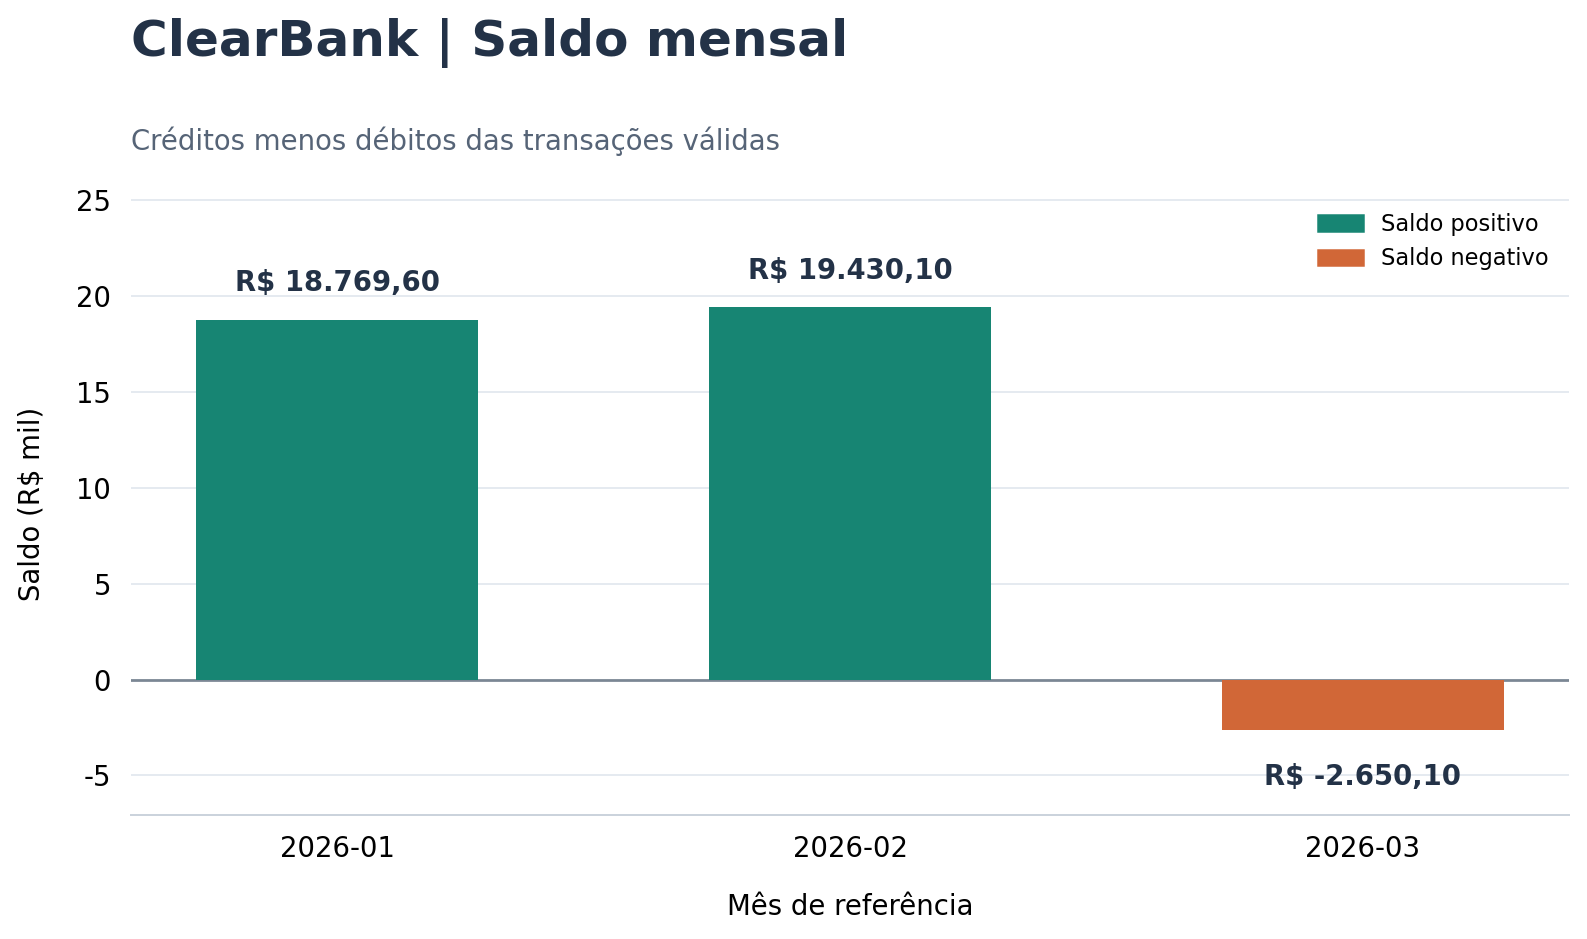

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from IPython.display import Image, display


def gerar_grafico(resultado, caminho="grafico.png"):
    """Gera o gráfico de barras do saldo mensal e salva em PNG."""
    meses = list(resultado["resumo_mensal"])
    saldos = [resultado["resumo_mensal"][mes]["saldo"] for mes in meses]
    if not meses:
        print("Sem transações válidas para gerar o gráfico.")
        return None
    positivo, negativo = "#178573", "#D16737"
    with plt.rc_context({"font.family": "DejaVu Sans", "font.size": 11}):
        fig, eixo = plt.subplots(figsize=(9.4, 5.4))
        fig.subplots_adjust(left=0.13, right=0.98, top=0.79, bottom=0.15)
        fig.suptitle("ClearBank | Saldo mensal", x=0.13, y=0.97,
                     ha="left", fontsize=20, fontweight="bold", color="#233247")
        eixo.set_title("Créditos menos débitos das transações válidas", loc="left",
                       fontsize=11, color="#566477", pad=17)
        eixo.bar(meses, saldos, width=0.55,
                 color=[positivo if saldo >= 0 else negativo for saldo in saldos], zorder=3)
        eixo.axhline(0, color="#7B8794", linewidth=1.1, zorder=2)
        eixo.grid(axis="y", color="#E5EAF0", linewidth=0.8, zorder=0)
        eixo.set_axisbelow(True)
        eixo.set_xlabel("Mês de referência", labelpad=12)
        eixo.set_ylabel("Saldo (R$ mil)", labelpad=12)
        eixo.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicao: f"{valor / 1000:g}"))
        amplitude = max(max(saldos), 0) - min(min(saldos), 0) or 1
        eixo.set_ylim(min(min(saldos), 0) - amplitude * 0.20,
                      max(max(saldos), 0) + amplitude * 0.27)
        for indice, saldo in enumerate(saldos):
            eixo.annotate(formatar_moeda(saldo), (indice, saldo),
                          xytext=(0, 9 if saldo >= 0 else -13), textcoords="offset points",
                          ha="center", va="bottom" if saldo >= 0 else "top",
                          fontweight="bold", color="#233247", fontsize=11)
        eixo.legend(handles=[Patch(color=positivo, label="Saldo positivo"),
                             Patch(color=negativo, label="Saldo negativo")],
                    loc="upper right", frameon=False, fontsize=9)
        for borda in ("top", "right", "left"):
            eixo.spines[borda].set_visible(False)
        eixo.spines["bottom"].set_color("#CBD3DC")
        eixo.tick_params(axis="both", length=0, pad=8)
        fig.savefig(caminho, dpi=180, facecolor="white", bbox_inches="tight")
        plt.close(fig)
    return Path(caminho)


arquivo_grafico = gerar_grafico(relatorio)
assert arquivo_grafico is not None and arquivo_grafico.is_file()
assert arquivo_grafico.read_bytes()[:8] == b"\x89PNG\r\n\x1a\n"
print("Gráfico de saldo mensal salvo em grafico.png.")
display(Image(filename=str(arquivo_grafico)))

## 12. Conferência final da entrega

O relatório pode ser reproduzido executando este notebook novamente.
A data em `gerado_em` acompanha a execução; as métricas da base fornecida
permanecem iguais. A auditoria externa `scripts/verificar_entrega.py` executa
o notebook em um kernel novo, confere todas as saídas e testa uma nova base.

In [12]:
relatorio_salvo = json.loads(ARQUIVO_JSON.read_text(encoding="utf-8"))
assert relatorio_salvo == relatorio == relatorio_pandas
assert relatorio_salvo["total_linhas_lidas"] == 33
assert relatorio_salvo["total_transacoes_validas"] == 18
assert relatorio_salvo["total_transacoes_invalidas"] == 15
assert len(relatorio_salvo["resumo_mensal"]) == 3
assert len(relatorio_salvo["transacoes_suspeitas"]) == 2
assert arquivo_grafico.name == "grafico.png"
print("CONFERÊNCIA FINAL APROVADA")
print("[OK] Solução principal com csv, datetime, funções e tratamento de erros")
print("[OK] 18 válidas, 15 inválidas, 3 meses e 2 suspeitas")
print("[OK] Sete métricas mensais, período de 85 dias e relatório formatado")
print("[OK] relatorio.json salvo e lido de volta sem diferenças")
print("[OK] Opcional R01: pandas com resultados iguais à solução nativa")
print("[OK] Opcional R02: grafico.png salvo e exibido")

CONFERÊNCIA FINAL APROVADA
[OK] Solução principal com csv, datetime, funções e tratamento de erros
[OK] 18 válidas, 15 inválidas, 3 meses e 2 suspeitas
[OK] Sete métricas mensais, período de 85 dias e relatório formatado
[OK] relatorio.json salvo e lido de volta sem diferenças
[OK] Opcional R01: pandas com resultados iguais à solução nativa
[OK] Opcional R02: grafico.png salvo e exibido
